In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
import sqlite3 as db
import warnings
warnings.filterwarnings("ignore")

In [12]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_holc = pd.read_sql_query("""
                                SELECT
                                    m.NPA
                                    , household_income
                                    , home_ownership
                                    , rental_houses
                                    , food_nutrition
                                    , employment
                                    , housing_age
                                    , code_violations
                                    , foreclosures
                                    , new_constructions
                                    , housing_density
                                    , age_of_residents
                                    , race_black
                                    , race_white
                                    , race_hispanic
                                    , race_asian
                                    , race_other
                                    , transit_proximity
                                    , financial_proximity
                                    , grocery_proximity
                                    , housing_cost_burden
                                    , displacement_risk
                                    , crime_total
                                    , h.grade
                                    , h.grade_category
                                FROM master AS m
                                LEFT JOIN npa_holc AS h 
                                    ON m.NPA = h.npa
                                """, conn)

conn.close()
print(f"Data loaded successfully. Master dataset shape:, {master_holc.shape[0]} records, {master_holc.shape[1]} features.")
display(master_holc.head())



Data loaded successfully. Master dataset shape:, 458 records, 25 features.


,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total,grade,grade_category
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,-0.618768,1.897747,0.242736,-0.292939,0.376054,0.278606,0,0.581649,None,None
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,-0.224057,-0.070897,9.043236,10.992720,9.194680,0.284134,0,3.480599,C,Definitely Declining
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,-0.260578,-1.391047,-0.560484,-0.551553,-0.673864,0.151362,0,-0.618596,None,None
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-0.697429,-0.009136,-0.578973,-0.546764,-0.750563,0.313884,1,-0.264850,C,Definitely Declining
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,-0.791542,-0.541828,-0.078758,0.062656,-0.143792,0.633077,1,1.814352,C,Definitely Declining


In [21]:
# Filter to only NPAs with HOLC grade assignments
holc_df = master_holc[master_holc["grade"].notna()].copy()

# Summary statistics
print(f"HOLC-graded NPAs: {holc_df.shape[0]}")
print(f"\nGrade distribution:")
print("="*20)
print(holc_df["grade"].value_counts().sort_index())

print(f"\nDisplacement risk by grade:")
print("="*20)
print(holc_df.groupby("grade")["displacement_risk"].value_counts())

print(f"\nMean housing cost burden by grade:")
print("="*20)
print(holc_df.groupby("grade")["housing_cost_burden"].mean().sort_index())

HOLC-graded NPAs: 41

Grade distribution:
grade
A     2
B     5
C    16
D    18
Name: count, dtype: int64

Displacement risk by grade:
grade  displacement_risk
A      0                     2
B      0                     5
C      1                    12
       0                     4
D      1                    11
       0                     7
Name: count, dtype: int64

Mean housing cost burden by grade:
grade
A    0.182698
B    0.206456
C    0.376588
D    0.382934
Name: housing_cost_burden, dtype: float64


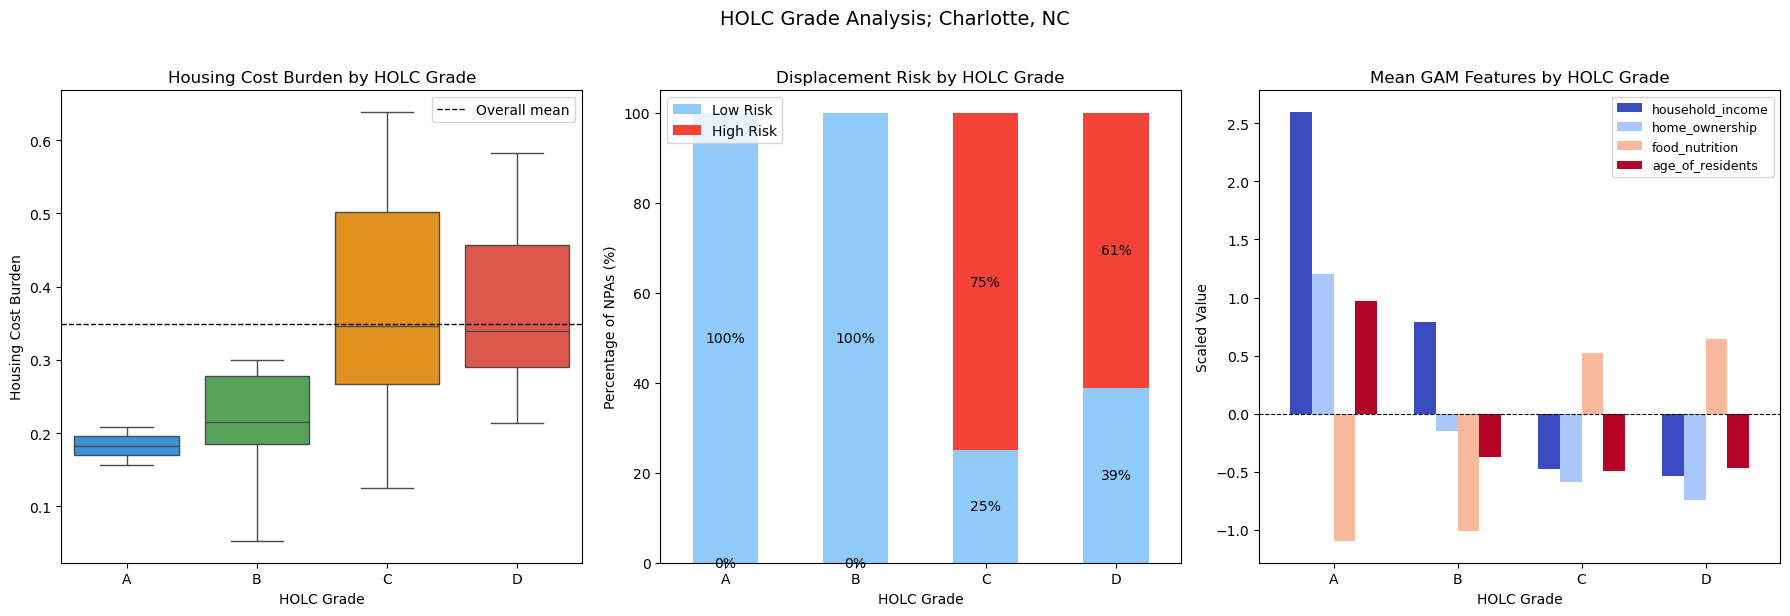

In [22]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Box plot: housing cost burden by grade
sns.boxplot(
    data=holc_df, x="grade", y="housing_cost_burden",
    order=["A", "B", "C", "D"],
    palette={"A": "#2196F3", "B": "#4CAF50", "C": "#FF9800", "D": "#F44336"},
    ax=axes[0]
)
axes[0].set_title("Housing Cost Burden by HOLC Grade")
axes[0].set_xlabel("HOLC Grade")
axes[0].set_ylabel("Housing Cost Burden")
axes[0].axhline(holc_df["housing_cost_burden"].mean(), 
                color="black", linestyle="--", lw=1, label="Overall mean")
axes[0].legend()


# Stacked bar: displacement risk by grade
risk_counts = holc_df.groupby(["grade", "displacement_risk"]).size().unstack(fill_value=0)
risk_pct = risk_counts.div(risk_counts.sum(axis=1), axis=0) * 100
risk_pct = risk_pct.reindex(["A", "B", "C", "D"])

risk_pct.plot(
    kind="bar", stacked=True,
    color=["#90CAF9", "#F44336"],
    ax=axes[1],
    width=0.5
)
axes[1].set_title("Displacement Risk by HOLC Grade")
axes[1].set_xlabel("HOLC Grade")
axes[1].set_ylabel("Percentage of NPAs (%)")
axes[1].set_xticklabels(["A", "B", "C", "D"], rotation=0)
axes[1].legend(["Low Risk", "High Risk"], loc="upper left")

for bar_group in axes[1].containers:
    axes[1].bar_label(bar_group, fmt="%.0f%%", label_type="center", fontsize=10)


# Bar chart: mean GAM features by grade
feature_means = holc_df.groupby("grade")[
    ["household_income", "home_ownership", "food_nutrition", "age_of_residents"]
].mean().reindex(["A", "B", "C", "D"])

feature_means.plot(
    kind="bar",
    ax=axes[2],
    width=0.7,
    colormap="coolwarm"
)
axes[2].set_title("Mean GAM Features by HOLC Grade")
axes[2].set_xlabel("HOLC Grade")
axes[2].set_ylabel("Scaled Value")
axes[2].set_xticklabels(["A", "B", "C", "D"], rotation=0)
axes[2].axhline(0, color="black", linestyle="--", lw=0.8)
axes[2].legend(loc="upper right", fontsize=9)


plt.suptitle("HOLC Grade Analysis; Charlotte, NC", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Visual Analysis

**Housing Cost Burden by HOLC Grade**

The box plot reveals a clear gradient in housing cost burden from A to D, 
with grades A and B falling well below the overall mean and showing tight, 
consistent distributions. Grades C and D both sit at or above the mean, 
though with a notable distinction — grade C shows the widest interquartile 
range of any group, suggesting these neighborhoods are in transition, with 
some still affordable and others already under significant pressure. Grade D 
neighborhoods, by contrast, are more uniformly burdened with a tighter and 
slightly lower spread than C, indicating that displacement pressure in the 
most heavily redlined areas has already stabilized at a persistently high level.

**Displacement Risk by HOLC Grade**

Grades A and B are composed entirely of Low Risk neighborhoods. Grade C shows 
the sharpest shift, with 75% of its neighborhoods classified as High Risk — 
a more striking proportion than even grade D at 61%. This suggests that 
C-graded neighborhoods, which were historically deemed marginally acceptable 
by HOLC assessors, may now be experiencing active gentrification pressure as 
development encroaches on formerly borderline areas. Grade D neighborhoods, 
while still majority High Risk, show a slightly more mixed picture, possibly 
reflecting the fact that some have been low-investment for so long that 
gentrification has not yet reached them.

**Mean GAM Features by HOLC Grade**

The feature bar chart provides the mechanistic link between historical grade 
and present-day outcomes. The four features identified by the GAM as the 
primary drivers of housing cost burden — household income, home ownership, 
food nutrition reliance, and age of residents — all track systematically with 
HOLC grade. Household income is highest in grade A neighborhoods and declines 
steadily through D. Home ownership rates are above average in A and B but turn 
negative in C and D. Food nutrition reliance, a proxy for neighborhood poverty, 
is low in A and B and rises in C and D. Age of residents follows a similar 
pattern, with older populations concentrated in higher-graded neighborhoods. 
The consistency of this gradient across all four features simultaneously 
suggests that the socioeconomic conditions measured today are not incidental 
to historical grade — they are structurally embedded in it.

In [ ]:
# Kruskal-Wallis on housing_cost_burden
groups_burden = [
    holc_df[holc_df["grade"] == g]["housing_cost_burden"].values
    for g in ["A", "B", "C", "D"]
]

h_burden, p_burden = kruskal(*groups_burden)
print("=" * 55)
print("Kruskal-Wallis Test: Housing Cost Burden")
print("=" * 55)
print(f"H statistic: {h_burden:.4f}")
print(f"P-value:     {p_burden:.4f}")
print(f"Result:      {'Significant' if p_burden < 0.05 else 'Not significant'}")

# Kruskal-Wallis on displacement_risk
groups_risk = [
    holc_df[holc_df["grade"] == g]["displacement_risk"].values
    for g in ["A", "B", "C", "D"]
]

h_risk, p_risk = kruskal(*groups_risk)
print()
print("=" * 55)
print("Kruskal-Wallis Test: Displacement Risk")
print("=" * 55)
print(f"H statistic: {h_risk:.4f}")
print(f"P-value:     {p_risk:.4f}")
print(f"Result:      {'Significant' if p_risk < 0.05 else 'Not significant'}")

Kruskal-Wallis Test — Housing Cost Burden
H statistic: 9.6994
P-value:     0.0213
Result:      Significant

Kruskal-Wallis Test — Displacement Risk
H statistic: 11.1702
P-value:     0.0108
Result:      Significant


### Kruskal-Wallis Test Results

To detremine whether the observed differences across HOLC grades were statistically significant, Kruskal-Wallis tests were performed on both target variables. This test was chosen over ANOVA due to the small and unequal group sizes... in  particular for grades A (n=2) and B (n=5), which preclude normality assumptions.

Results were significant for both outcomes, where distribution of each variable differed across HOLC grades:

- **Housing Cost Burden**: H=9.70, p=0.0213
- **Displacement Risk**: H=11.17, p=0.0108

These findings confirm that the box plot and stacked bar chart are statistically reliable and not attributable to chance variation across the small sample of 41 HOLC-graded NPAs. 
Neighborhoods historically graded C and D show systematically higher housing cost burden and displacement risk than those graded A and B, suggesting that the structural disadvantages encoded in Charlotte's HOLC redlining practices between 1935 - 1968 remain statistically detectable in Charlotte's neighborhood outcomes today.